# Practice for Aggregating, Reshaping, and Combining Dataframes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Load customer demographics and claims information into separate dataframes:
- customer demographics should be loaded into `cust_df` from 'cust_demographics.csv'
- claims should be loaded into `claims_df` from 'claims.csv'

In [2]:
cust_df = pd.read_csv('cust_demographics.csv', parse_dates=['DateOfBirth'])
claims_df = pd.read_csv('claims.csv', parse_dates=['claim_date'])

C:\Users\markh\AppData\Local\Temp\ipykernel_21764\1566001312.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cust_df = pd.read_csv('cust_demographics.csv', parse_dates=['DateOfBirth'])


2. Inspect the DataFrames to get an understanding of the data, dtypes, and column structure

In [3]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CUST_ID      1087 non-null   int64         
 1   gender       1087 non-null   object        
 2   DateOfBirth  1087 non-null   datetime64[ns]
 3   State        1087 non-null   object        
 4   Contact      1087 non-null   object        
 5   Segment      1087 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 51.1+ KB


In [4]:
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   claim_id             1104 non-null   int64         
 1   customer_id          1104 non-null   int64         
 2   incident_cause       1104 non-null   object        
 3   claim_date           1104 non-null   datetime64[ns]
 4   claim_area           1104 non-null   object        
 5   police_report        1104 non-null   object        
 6   claim_type           1104 non-null   object        
 7   claim_amount         1100 non-null   object        
 8   total_policy_claims  1104 non-null   int64         
 9   fraudulent           1104 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 86.4+ KB


3. Check for duplicates and then remove them:

In [7]:
cust_df.duplicated(subset=['CUST_ID']).sum()

2

In [8]:
cust_df = cust_df.drop_duplicates(subset=['CUST_ID'])

In [10]:
claims_df.duplicated(subset=['claim_id']).sum()

4

In [11]:
claims_df = claims_df.drop_duplicates(subset=['claim_id'])

4. Join the dataframes and save to a dataframe `combined_df`. Identify what column(s) you will join on and then use an inner join. Drop any redundant columns resulting from merge:

In [12]:
cust_df.rename(columns={'CUST_ID': 'customer_id'}, inplace=True)
combined_df = pd.merge(cust_df, claims_df, on='customer_id', how='inner', suffixes=['_cust', '_claims'])
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          1085 non-null   int64         
 1   gender               1085 non-null   object        
 2   DateOfBirth          1085 non-null   datetime64[ns]
 3   State                1085 non-null   object        
 4   Contact              1085 non-null   object        
 5   Segment              1085 non-null   object        
 6   claim_id             1085 non-null   int64         
 7   incident_cause       1085 non-null   object        
 8   claim_date           1085 non-null   datetime64[ns]
 9   claim_area           1085 non-null   object        
 10  police_report        1085 non-null   object        
 11  claim_type           1085 non-null   object        
 12  claim_amount         1081 non-null   object        
 13  total_policy_claims  1085 non-nul

5. Identify cleaning tasks in the `claim_amount` column and execute them:

In [13]:
combined_df = combined_df.dropna()

combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1081 entries, 0 to 1084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          1081 non-null   int64         
 1   gender               1081 non-null   object        
 2   DateOfBirth          1081 non-null   datetime64[ns]
 3   State                1081 non-null   object        
 4   Contact              1081 non-null   object        
 5   Segment              1081 non-null   object        
 6   claim_id             1081 non-null   int64         
 7   incident_cause       1081 non-null   object        
 8   claim_date           1081 non-null   datetime64[ns]
 9   claim_area           1081 non-null   object        
 10  police_report        1081 non-null   object        
 11  claim_type           1081 non-null   object        
 12  claim_amount         1081 non-null   object        
 13  total_policy_claims  1081 non-null   i

In [15]:
combined_df.head()

,customer_id,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,1979-01-12,VT,789-916-8172,Platinum,54004764,Driver error,2017-11-27,Auto,No,Material only,$2980,1,No
1,75740424,Female,2070-01-13,ME,265-543-1264,Silver,33985796,Crime,2018-10-03,Home,Unknown,Material only,$2980,3,No
2,30308357,Female,1984-03-11,TN,798-631-4758,Silver,53522022,Other driver error,2018-02-02,Auto,No,Material only,$3369.5,1,Yes
3,30308357,Female,1984-03-11,TN,798-631-4758,Silver,63017412,Driver error,2018-04-04,Auto,No,Material only,$1950,6,No
4,47830476,Female,1986-05-01,MA,413-187-7945,Silver,13015401,Natural causes,2018-06-17,Auto,No,Material only,$1680,1,No


In [16]:
combined_df['claim_amount'] = combined_df['claim_amount'].str.replace('$', '').astype('float')
combined_df.head(3)

,customer_id,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,1979-01-12,VT,789-916-8172,Platinum,54004764,Driver error,2017-11-27,Auto,No,Material only,2980.0,1,No
1,75740424,Female,2070-01-13,ME,265-543-1264,Silver,33985796,Crime,2018-10-03,Home,Unknown,Material only,2980.0,3,No
2,30308357,Female,1984-03-11,TN,798-631-4758,Silver,53522022,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1,Yes


6. Clean the fraudulent column and conver to appropriate numeric values.

In [17]:
# check category value counts
print(combined_df['fraudulent'].value_counts())

fraudulent
No     834
Yes    247
Name: count, dtype: int64


In [18]:
combined_df['fraudulent'] = (combined_df['fraudulent'] == 'Yes').astype('int')

In [19]:
combined_df.head(3)

,customer_id,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,1979-01-12,VT,789-916-8172,Platinum,54004764,Driver error,2017-11-27,Auto,No,Material only,2980.0,1,0
1,75740424,Female,2070-01-13,ME,265-543-1264,Silver,33985796,Crime,2018-10-03,Home,Unknown,Material only,2980.0,3,0
2,30308357,Female,1984-03-11,TN,798-631-4758,Silver,53522022,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1,1


7. Use an appropriate plot to visualize the the mean claim amount for each incidence cause:

In [21]:
cause_dependence = combined_df.groupby('incident_cause')[['claim_amount', 'fraudulent']].mean(numeric_only=True)
cause_dependence

,claim_amount,fraudulent
incident_cause,,
Crime,6546.564815,0.240741
Driver error,13756.873077,0.226923
Natural causes,7308.886486,0.210811
Other causes,14570.896491,0.249123
Other driver error,14720.043210,0.213992


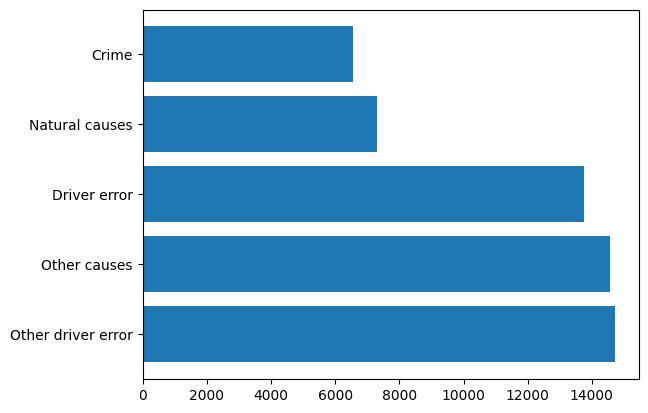

In [22]:
claim_amt = cause_dependence['claim_amount'].sort_values(ascending=False)
fig, ax = plt.subplots()
ax.barh(y = claim_amt.index, width=claim_amt.values)
plt.show()

8. Plot the distribution of claim amounts: use a histogram.

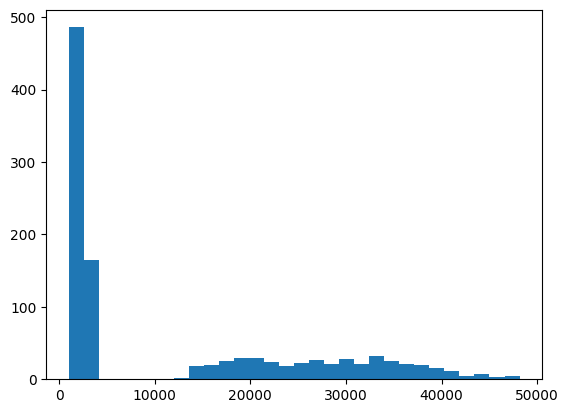

In [23]:
plt.hist(combined_df['claim_amount'], bins = 30)
plt.show()

9. There is a bimodal distribution here. Create a binary column called "claim_size" that is "large" when the claim amount is greater than or equal to 10000 and "small" otherwise. We will use this binary categorical later.

In [24]:
combined_df['claim_size'] = (combined_df['claim_amount'] >= 10000).map({True: 'large', False: 'small'})

combined_df.head(3)

,customer_id,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,claim_size
0,21868593,Female,1979-01-12,VT,789-916-8172,Platinum,54004764,Driver error,2017-11-27,Auto,No,Material only,2980.0,1,0,small
1,75740424,Female,2070-01-13,ME,265-543-1264,Silver,33985796,Crime,2018-10-03,Home,Unknown,Material only,2980.0,3,0,small
2,30308357,Female,1984-03-11,TN,798-631-4758,Silver,53522022,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1,1,small


10. Investigate the fraudulent claim rate by state:
- get the rate of fraudulent claims by state sorted in descending order. Save this to a Series `sorted_rates`
- get the states with the top 15 fraudulent claim rates and save this list of state to `state_names`.

In [26]:
sorted_rates = combined_df.groupby('State')['fraudulent'].mean(numeric_only=True).sort_values(ascending=False)
state_names = sorted_rates[0:15].index
print(sorted_rates[0:15])
state_names

State
TN    0.555556
KY    0.428571
MT    0.400000
NM    0.368421
OR    0.357143
CA    0.352941
WI    0.347826
DE    0.344828
ID    0.333333
MI    0.333333
TX    0.318182
WV    0.300000
WY    0.294118
AL    0.285714
MA    0.269231
Name: fraudulent, dtype: float64


Index(['TN', 'KY', 'MT', 'NM', 'OR', 'CA', 'WI', 'DE', 'ID', 'MI', 'TX', 'WV',
       'WY', 'AL', 'MA'],
      dtype='object', name='State')

11. It would be interesting to see whether there is a differentiation of fraud rates by claim size in each state. First compute this by using a pivot table. Display results from the states with the top 15 highest fraudulent claim rates.


In [27]:
widestateclaims = combined_df.pivot_table(index = 'State', columns = 'claim_size', values='fraudulent')
widestateclaims.loc[state_names]

claim_size,large,small
State,,
TN,0.444444,0.611111
KY,0.333333,0.454545
MT,0.416667,0.375000
NM,0.333333,0.400000
OR,0.200000,0.444444
CA,0.375000,0.333333
WI,0.300000,0.384615
DE,0.333333,0.352941
ID,0.400000,0.294118


12. Conduct a groupby/aggregation(s) by State and claim size. This time you will compute the fraudulent claim rate as well as the number of examples in each category and subcategory. The result should be presented in a single DataFrame.

*Hint*: you can compute each aggregation separately and then concatenate **or** you can look up how to perform multiple aggregations with the .agg() method.

In [28]:
groupedstateclaims_mean = combined_df.groupby(['State','claim_size'])["fraudulent"].mean().rename('fraud_rate')
groupedstateclaims_count = combined_df.groupby(['State','claim_size'])["fraudulent"].count().rename('count')

groupedstateclaims = pd.concat([groupedstateclaims_mean, groupedstateclaims_count], axis = 1)
groupedstateclaims.head()

fraud_rate  count
State claim_size                   
AK    large         0.333333      9
      small         0.181818     11
AL    large         0.363636     11
      small         0.235294     17
AR    large         0.111111      9

There are not too many examples within each subgroup -- but it is plausible that there are enough here to differentiate between fraud behavior for small and large claims in many of the states.


13. Plot fraudulent rates amongst small and large claim sizes in the 15 states with the top average fraudulent rates:
- put this in a single bar chart with large and small claim sizes overlayed on top of each other
- use blue for large claim and orange for small claim, set transparency parameter to 0.4.
- make sure that you label plots appropriately and display legends.

*Hint*: selecting the appropriate column and unstacking the results of your groubpy on State and claim size might be helpful here

In [29]:
# unstacking

claims_fraud_state = groupedstateclaims.loc[state_names,'fraud_rate'].unstack()
claims_fraud_state.head()

claim_size,large,small
State,,
TN,0.444444,0.611111
KY,0.333333,0.454545
MT,0.416667,0.375000
NM,0.333333,0.400000
OR,0.200000,0.444444


claim_size,large,small
State,,
TN,0.444444,0.611111
KY,0.333333,0.454545
MT,0.416667,0.375000
NM,0.333333,0.400000
OR,0.200000,0.444444
CA,0.375000,0.333333
WI,0.300000,0.384615
DE,0.333333,0.352941
ID,0.400000,0.294118


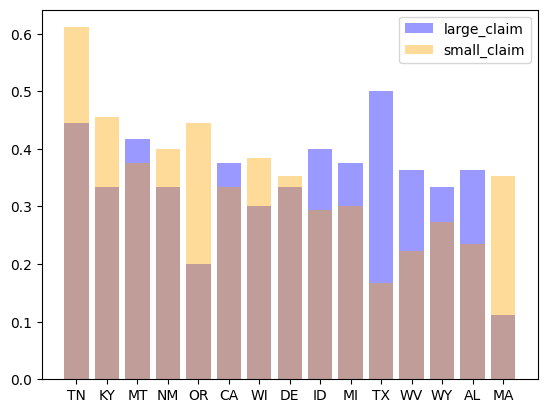

In [30]:
fig, ax = plt.subplots()
ax.bar(x = claims_fraud_state.index, height = claims_fraud_state['large'], color ='b', alpha = 0.4, label = 'large_claim')
ax.bar(x = claims_fraud_state.index, height = claims_fraud_state['small'], color ='orange', alpha = 0.4, label = 'small_claim')
ax.legend()
claims_fraud_state

14. Just because its a lot of fun and good for you, melt the pivot table with average fraudulent rates (pivoted on State and claim size) for the states with top 15 highest overall fradulent rates. We have recalculated the table that is to be melted below from `combined_df` and have stored it in `widestateclaims`:
- make sure that the index is still State (look up what option for melt you need)
- the value should be named 'fraud_rate'
- save to `melted_claims`

In [31]:
widestateclaims = combined_df.pivot_table(index = 'State', columns = 'claim_size', values='fraudulent').loc[state_names]
widestateclaims

claim_size,large,small
State,,
TN,0.444444,0.611111
KY,0.333333,0.454545
MT,0.416667,0.375000
NM,0.333333,0.400000
OR,0.200000,0.444444
CA,0.375000,0.333333
WI,0.300000,0.384615
DE,0.333333,0.352941
ID,0.400000,0.294118


In [32]:
melted_claims = pd.melt(widestateclaims, value_vars=['small', 'large'], value_name='fraud_rate', ignore_index=False)
melted_claims.head()

,claim_size,fraud_rate
State,,
TN,small,0.611111
KY,small,0.454545
MT,small,0.375000
NM,small,0.400000
OR,small,0.444444


15. [optional] There are a lot of other aspects of the data that we have not touched. In particular, it might be interesting to look at how claimant age and gender influence claim behavior. You could also take a look at incident cause and whether a police report was filed or not in seeing how fraudulent claims and claim size are influenced by these two categorical classes. Knock yourself out and use your reshaping and visualization skills to explore.